In [9]:
from pyinaturalist import *
import ridgeplot as rp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

In [44]:
taxa = {55626: 'Pieris rapae', 48662: 'Danaus plexippus', 58532: 'Colias eurytheme', 56832: 'Nymphalis antiopa', 54064: 'Polygonia comma', 49133: 'Vanessa atalanta', 58523: 'Papilio polyxenes', 48550: 'Phoebis sennae', 1613196: 'Papilio glaucus', 81559: 'Epargyreus clarus'}
taxon_ids = [key for key, value in taxa.items()]
print(taxon_ids)

[55626, 48662, 58532, 56832, 54064, 49133, 58523, 48550, 1613196, 81559]


In [92]:
# Convert months to approximate middle-of-month day of year
month_days = np.array([
    15,   # January
    46,   # February
    74,   # March
    105,  # April
    135,  # May
    166,  # June
    196,  # July
    227,  # August
    258,  # September
    288,  # October
    319,  # November
    349   # December
])

days = np.arange(1, 366)

In [93]:
def get_curve(taxon_id):
    histogram = get_observation_histogram(taxon_id=taxon_id, place_id=42, quality_grade='research')
    
    months = np.array(list(histogram.keys()))
    observations = np.array(list(histogram.values()))
    
    interpolator = PchipInterpolator(month_days, observations)
    daily_observations = interpolator(days)
    
    # Normalize to maximum = 1
    daily_normalized = daily_observations / daily_observations.max()
    
    return daily_normalized

In [59]:
phenology = {}

for taxon in taxon_ids:
    phenology[taxon] = get_curve(taxon)

0 Pieris rapae
0.0
1 Danaus plexippus
0.55
2 Colias eurytheme
1.1
3 Nymphalis antiopa
1.6500000000000001
4 Polygonia comma
2.2
5 Vanessa atalanta
2.75
6 Papilio polyxenes
3.3000000000000003
7 Phoebis sennae
3.8500000000000005
8 Papilio glaucus
4.4
9 Epargyreus clarus
4.95


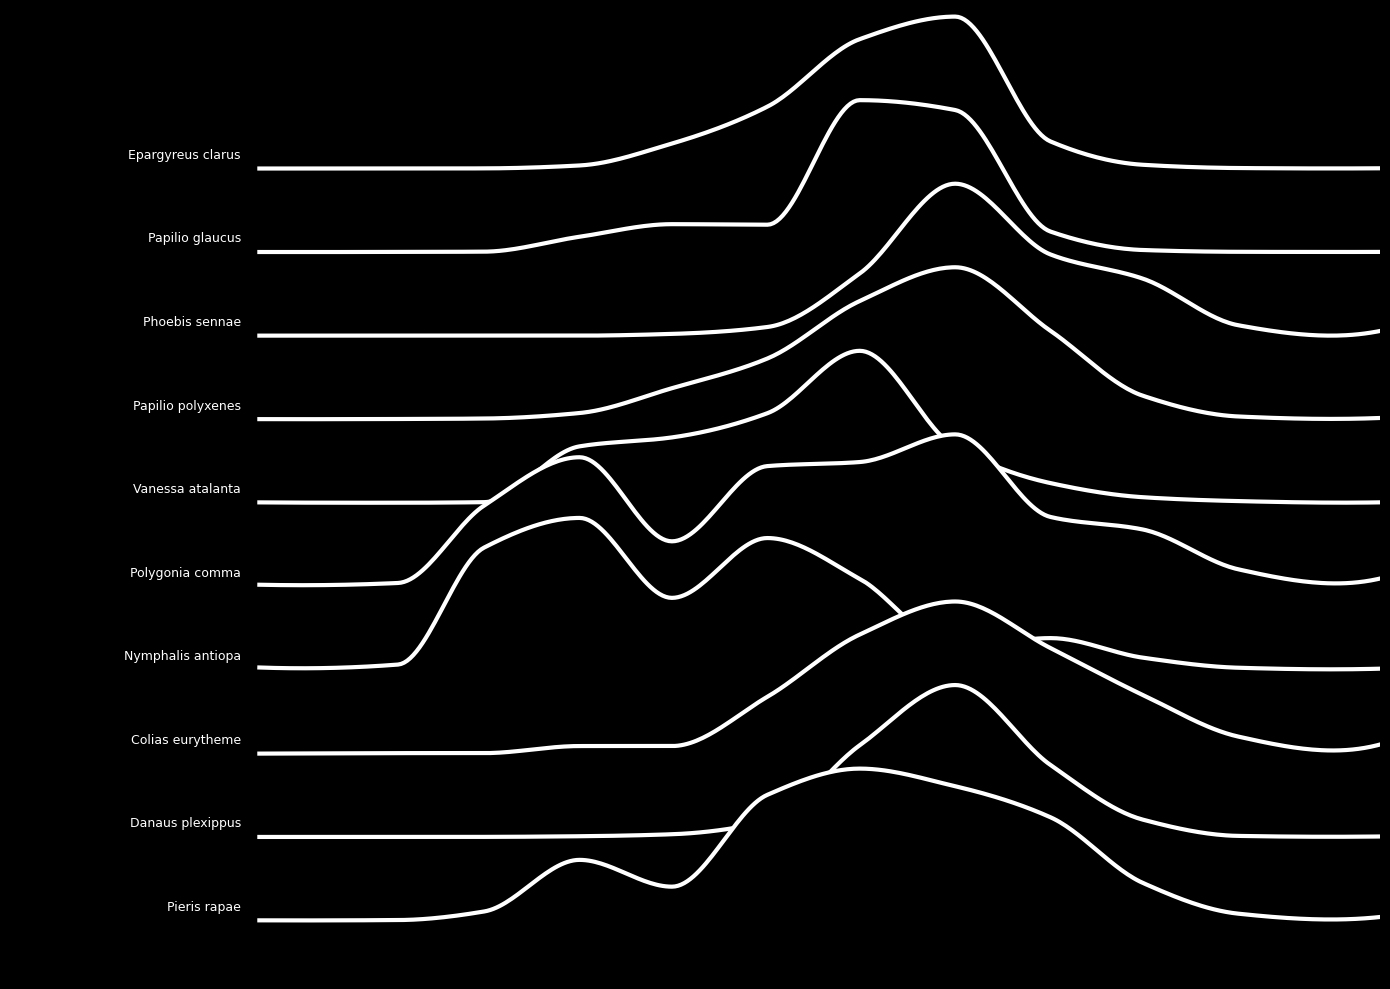

In [117]:
# Plot
fig, ax = plt.subplots(figsize=(14, 10))

fig.patch.set_facecolor("black")
ax.set_facecolor("black")

spacing = 0.55

for i, (taxon, curve) in enumerate(phenology.items()):

    print(i, taxa[taxon])

    baseline = i * spacing
    print(baseline)
    y = baseline + curve

    ax.fill_between(
        days,
        y,
        color="black",
        zorder=len(phenology)-i
    )
    
    ax.plot(
        days,
        y,
        linewidth=3,
        color="white",
        zorder=len(phenology)-i
    )

    # Species label
    ax.text(
        -5,
        baseline + 0.05,
        taxa[taxon],
        ha="right",
        va="bottom",
        fontsize=9,
        color="white"
    )


# Formatting
ax.set_xlim(-80, 365)
ax.set_ylim(-0.1, (len(phenology) - 1) * spacing + 1.05)

ax.set_yticks([])

ax.set_xlabel("Day of year")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()